In [1]:
from tensorflow import keras
import pandas as pd 
import numpy as np 
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt 
import seaborn as sns 
import os 
from datetime import datetime

In [2]:
data=pd.read_csv("MSFT.csv")

In [3]:
data.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,1986-03-13,0.088542,0.101563,0.088542,0.097222,0.061434,1031788800
1,1986-03-14,0.097222,0.102431,0.097222,0.100694,0.063628,308160000
2,1986-03-17,0.100694,0.103299,0.100694,0.102431,0.064725,133171200
3,1986-03-18,0.102431,0.103299,0.098958,0.099826,0.063079,67766400
4,1986-03-19,0.099826,0.100694,0.097222,0.098090,0.061982,47894400


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9083 entries, 0 to 9082
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       9083 non-null   object 
 1   Open       9083 non-null   float64
 2   High       9083 non-null   float64
 3   Low        9083 non-null   float64
 4   Close      9083 non-null   float64
 5   Adj Close  9083 non-null   float64
 6   Volume     9083 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 496.9+ KB


In [5]:
data.describe()

,Open,High,Low,Close,Adj Close,Volume
count,9083.000000,9083.000000,9083.000000,9083.000000,9083.000000,9.083000e+03
mean,41.324936,41.760887,40.878488,41.335628,36.256120,5.875055e+07
std,59.696905,60.272218,59.081728,59.714567,59.981436,3.845200e+07
min,0.088542,0.092014,0.088542,0.090278,0.057046,2.304000e+06
25%,4.050781,4.102051,4.027344,4.075195,2.575089,3.461230e+07
50%,26.820000,27.100000,26.520000,26.840000,18.948530,5.203200e+07
75%,40.034999,40.443751,39.500000,39.937500,29.244812,7.265400e+07
max,344.619995,349.670013,342.200012,343.109985,342.402008,1.031789e+09


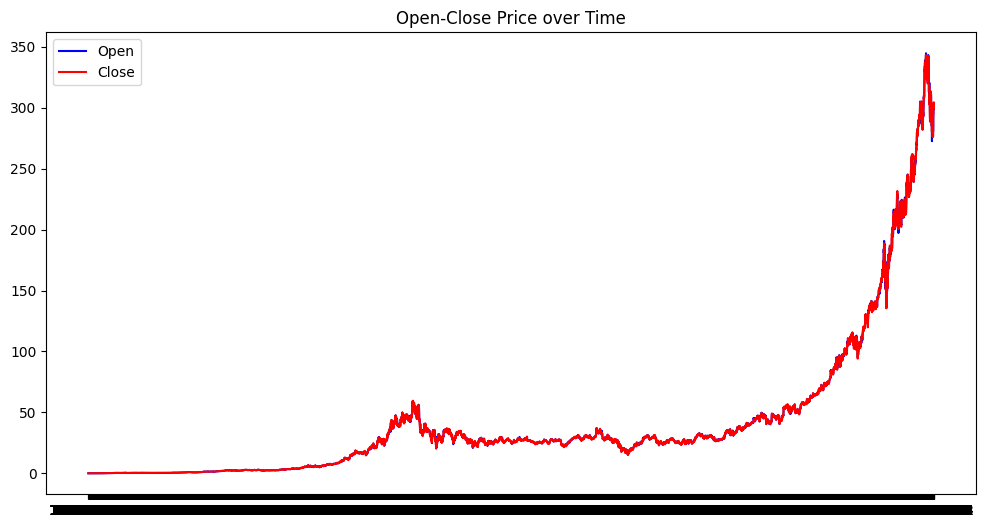

In [ ]:
# Plot 1 - Open and Close Prices of time
plt.figure(figsize=(12,6))
plt.plot(data['Date'], data['Open'], label="Open",color="blue")
plt.plot(data['Date'], data['Close'], label="Close",color="red")
plt.title("Open-Close Price over Time")
plt.legend()
#plt.show()

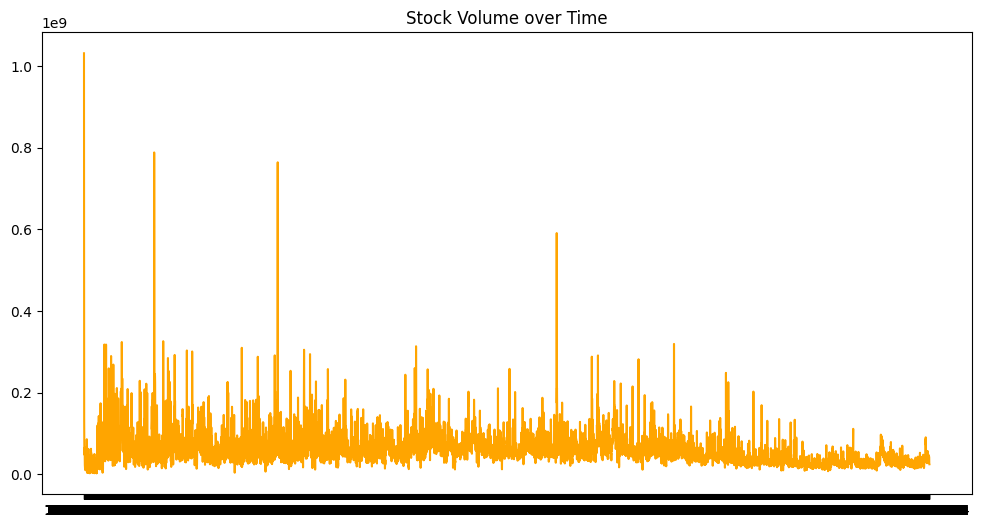

In [ ]:
# Plot 2 - Trading Volume (check for outliers)
plt.figure(figsize=(12,6))
plt.plot(data['Date'],data['Volume'],label="Volume",color="orange")
plt.title("Stock Volume over Time")
#plt.show()

In [11]:
numeric_data=data.select_dtypes(include=["int64","float64"])

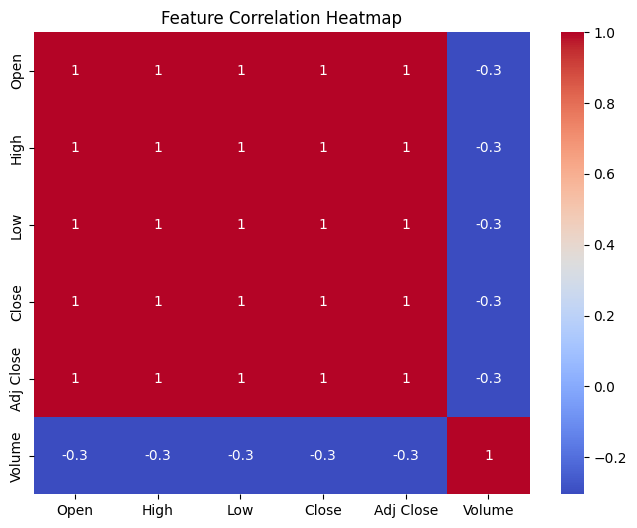

In [ ]:
# Plot 3 - Check for correlation between features
plt.figure(figsize=(8,6))
sns.heatmap(numeric_data.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
#plt.show()

In [13]:
# Convert the Data into Date time then create a date filter
data['Date'] = pd.to_datetime(data['Date'])

Text(0.5, 1.0, 'Price over time')

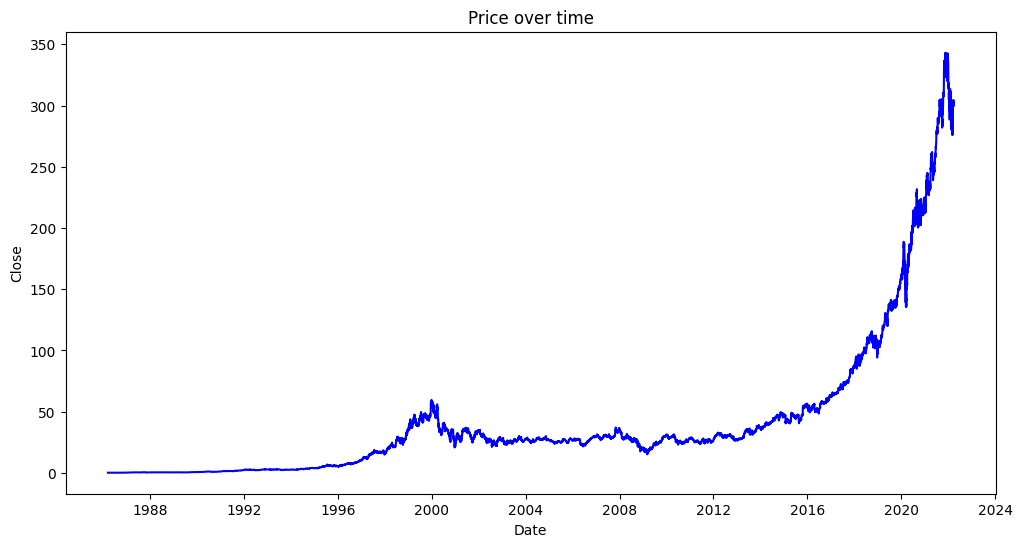

In [14]:
plt.figure(figsize=(12,6))
plt.plot(data['Date'], data['Close'],color="blue")
plt.xlabel("Date")
plt.ylabel("Close")
plt.title("Price over time")

In [17]:
# Prepare for the LSTM Model (Sequential)
stock_close = data.filter(["Close"])
dataset = stock_close.values #convert to numpy array
training_data_len = int(np.ceil(len(dataset) * 0.95))

In [18]:
# Preprocessing Stages
scaler = StandardScaler()
scaled_data = scaler.fit_transform(dataset)

In [19]:
training_data = scaled_data[:training_data_len] #95% of all out data
X_train, y_train = [], []

In [20]:
# Create a sliding window for our stock (60 days)
for i in range(60, len(training_data)):
    X_train.append(training_data[i-60:i, 0])
    y_train.append(training_data[i,0])

In [21]:
X_train, y_train = np.array(X_train), np.array(y_train)
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

In [22]:
# Build the Model
model = keras.models.Sequential()

# First Layer
model.add(keras.layers.LSTM(64, return_sequences=True, input_shape=(X_train.shape[1],1)))

# Second Layer
model.add(keras.layers.LSTM(64, return_sequences=False))

# 3rd Layer (Dense)
model.add(keras.layers.Dense(128, activation="relu"))

# 4th Layer (Dropout)
model.add(keras.layers.Dropout(0.5))

# Final Output Layer
model.add(keras.layers.Dense(1))

c:\Users\VEDANT THAKER\anaconda3\envs\mlbootcamp\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [23]:
model.summary()
model.compile(optimizer="adam",
              loss="mae",
              metrics=[keras.metrics.RootMeanSquaredError()])

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,369 (228.00 KB)

 Trainable params: 58,369 (228.00 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
training = model.fit(X_train, y_train, epochs=20, batch_size=32)

Epoch 1/20
268/268 ━━━━━━━━━━━━━━━━━━━━ 15s 45ms/step - loss: 0.0743 - root_mean_squared_error: 0.1325
Epoch 2/20
268/268 ━━━━━━━━━━━━━━━━━━━━ 24s 91ms/step - loss: 0.0541 - root_mean_squared_error: 0.0904
Epoch 3/20
268/268 ━━━━━━━━━━━━━━━━━━━━ 23s 84ms/step - loss: 0.0499 - root_mean_squared_error: 0.0854
Epoch 4/20
268/268 ━━━━━━━━━━━━━━━━━━━━ 33s 54ms/step - loss: 0.0476 - root_mean_squared_error: 0.0830
Epoch 5/20
268/268 ━━━━━━━━━━━━━━━━━━━━ 21s 79ms/step - loss: 0.0455 - root_mean_squared_error: 0.0822
Epoch 6/20
268/268 ━━━━━━━━━━━━━━━━━━━━ 16s 59ms/step - loss: 0.0437 - root_mean_squared_error: 0.0791
Epoch 7/20
268/268 ━━━━━━━━━━━━━━━━━━━━ 18s 49ms/step - loss: 0.0428 - root_mean_squared_error: 0.0777
Epoch 8/20
268/268 ━━━━━━━━━━━━━━━━━━━━ 26s 70ms/step - loss: 0.0433 - root_mean_squared_error: 0.0808
Epoch 9/20
268/268 ━━━━━━━━━━━━━━━━━━━━ 17s 56ms/step - loss: 0.0406 - root_mean_squared_error: 0.0727
Epoch 10/20
268/268 ━━━━━━━━━━━━━━━━━━━━ 21s 79ms/step - loss: 0.0429 - r

In [25]:
# Prep the test data
test_data = scaled_data[training_data_len - 60:]
X_test, y_test = [], dataset[training_data_len:]
for i in range(60, len(test_data)):
    X_test.append(test_data[i-60:i, 0])
    
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1 ))

In [26]:
# Make a Prediction
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step


In [27]:
# Plotting data
train = data[:training_data_len]
test =  data[training_data_len:]

test=test.copy()

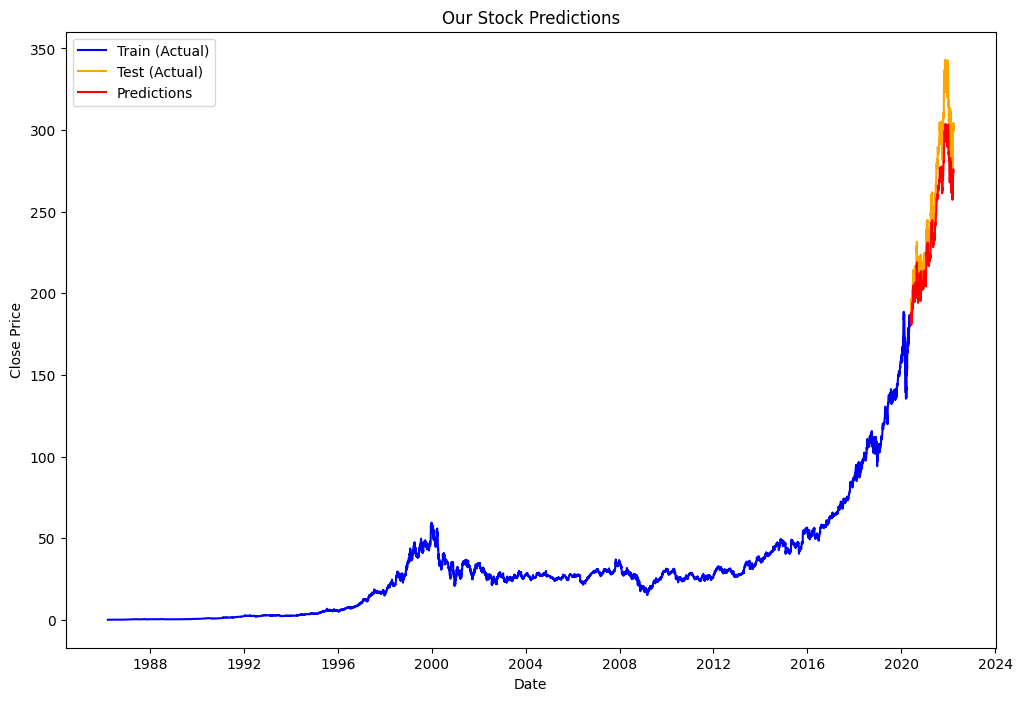

In [29]:
test['Predictions'] = predictions

plt.figure(figsize=(12,8))
plt.plot(train['Date'], train['Close'], label="Train (Actual)", color='blue')
plt.plot(test['Date'], test['Close'], label="Test (Actual)", color='orange')
plt.plot(test['Date'], test['Predictions'], label="Predictions", color='red')
plt.title("Our Stock Predictions")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.show()